# Disaster Relief Medical Donation Platform (R26-IT-047)
# Notebook 02: Disaster Risk Heatmaps, Feature Correlation & Spatial Visualizations

### Author / Component: Kavitha · Component Owner
### Module: Disaster Relief Medical Donation & Emergency Triage AI Module
---
## Analytical Objectives & Visual Index

This notebook presents an advanced **Matplotlib-driven geospatial and statistical visualization suite** for disaster analytics, risk mapping, and machine learning interpretability:

1. **Feature-to-Feature Correlation Heatmaps**: Pearson and Spearman correlation matrices across hydrological, demographic, exposure, and emergency triage parameters.
2. **2D Geospatial Hazard Heatmaps**: Spatial coordinates, Kernel Density Estimates (KDE), and hazard intensity contours for Kelani River Flood Basins and Nuwara Eliya Landslide zones.
3. **Medical Camp Viability Contour Heatmaps**: 2D geospatial suitability surface plots mapping safe zones, road accessibility gradients, and optimal relief hub zones.
4. **Machine Learning Decision Surface Heatmaps**: 2D decision manifolds showing how non-linear Random Forest boundaries segregate Low, Medium, and High hazard categories.
5. **Feature Importance Interpretability**: Mean Decrease in Impurity (Gini Importance) and feature weight rankings.

In [1]:
import os
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from scipy.stats import gaussian_kde

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
import joblib

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['figure.dpi'] = 150

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATASET_DIR = ROOT / "dataset"
MODEL_DIR = ROOT / "backend" / "ml_models"

print(f"Notebook 02 Environment Configured. Root: {ROOT.resolve()}")

Notebook 02 Environment Configured. Root: D:\My research\SDM Project refine


---
## 1. Feature Matrices Preparation & Correlation Analysis

We load the datasets and construct self-contained feature matrices for correlation heatmaps and geospatial plotting.

In [2]:
# 1.1 Load Datasets & Define Feature Schemas
# Feature Name Constants
LS_FEATURES = [
    "gn_encoded", "incident_count", "total_families", "total_people",
    "mean_families", "mean_people", "max_people", "std_people",
    "people_per_family", "severity_score"
]

FLOOD_FEATURES = [
    "latitude", "longitude", "dist_to_kelani_km", "proximity_score",
    "boggy_frac", "water_frac", "builtup_frac", "road_density",
    "elevation_proxy", "rainfall_proxy", "river_level_proxy", "is_kelani_zone"
]

CAMP_FEATURES = [
    "latitude", "longitude", "dist_to_kelani_km", "flood_risk_score", "landslide_risk_score",
    "sos_density", "road_accessibility", "critical_facility_nearby", "open_space_available", "elevation_suitability"
]

SOS_FEATURES = [
    "urgency", "affected_people", "affected_families", "has_elderly", "has_children", "has_disabled",
    "medical_needs_count", "flood_risk_score", "landslide_risk_score", "hours_since_sos", "access_difficulty"
]

# Landslide GND Aggregation
df_ls = pd.read_csv(DATASET_DIR / "Landslide_Cleaned.csv")
for col in df_ls.select_dtypes("object").columns:
    df_ls[col] = df_ls[col].str.strip()
df_ls["gn_name"] = df_ls["gn_division"].str.replace(r"^\d+\s+[A-Z]\s+", "", regex=True).str.strip()

gnd_stats = df_ls.groupby("gn_name").agg(
    incidents=("id", "count"),
    tot_fam=("affected_families", "sum"),
    tot_ppl=("affected_people", "sum"),
    mean_fam=("affected_families", "mean"),
    mean_ppl=("affected_people", "mean"),
    max_ppl=("affected_people", "max"),
    std_ppl=("affected_people", "std")
).reset_index().fillna(0)
gnd_stats["ppl_per_fam"] = gnd_stats["tot_ppl"] / gnd_stats["tot_fam"].replace(0, 1)

# Kelani River Basin Spatial Reference
df_gnd = pd.read_csv(DATASET_DIR / "Kaduwela_GN_Master.csv")
df_gnd = df_gnd.drop(columns=[c for c in df_gnd.columns if "Unnamed" in str(c)])
df_gnd_named = df_gnd.dropna(subset=["gn_division"]).copy()
df_kelani_pts = df_gnd[df_gnd["gn_division"].isna()].copy()

lat_center = df_kelani_pts["latitude"].mean()
lon_center = df_kelani_pts["longitude"].mean()

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlam/2)**2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

n_gnds = len(df_gnd_named)
lat = df_gnd_named["latitude"].values
lon = df_gnd_named["longitude"].values
dist = haversine_km(lat, lon, lat_center, lon_center)
proximity_score = np.clip(1 - (dist / dist.max()), 0, 1)

rng = np.random.RandomState(42)
rainfall_proxy = 1800 + 400 * proximity_score + rng.normal(0, 80, n_gnds)
river_level_proxy = 2.5 + 1.5 * proximity_score + rng.normal(0, 0.2, n_gnds)

# Calculate Flood Labels for Kaduwela GNDs
f_score_local = (
    0.35 * proximity_score +
    0.25 * np.clip((rainfall_proxy - 1600) / 800, 0, 1) +
    0.25 * np.clip((river_level_proxy - 2.0) / 2.5, 0, 1) +
    0.15 * rng.uniform(0, 1, n_gnds)
) * 100

y_flood = np.where(f_score_local <= np.percentile(f_score_local, 33), 0,
          np.where(f_score_local <= np.percentile(f_score_local, 67), 1, 2))

# Synthetic SOS Scenario Dataset
rng4 = np.random.RandomState(123)
n_sos = 600
df_sos = pd.DataFrame({
    "Urgency (1-5)": rng4.randint(1, 6, n_sos),
    "Affected People": rng4.randint(1, 50, n_sos),
    "Affected Families": rng4.randint(1, 20, n_sos),
    "Has Elderly": rng4.binomial(1, 0.3, n_sos),
    "Has Children": rng4.binomial(1, 0.4, n_sos),
    "Medical Needs": rng4.randint(0, 8, n_sos),
    "Flood Risk": rng4.uniform(0, 1, n_sos),
    "Landslide Risk": rng4.uniform(0, 1, n_sos),
    "Hours Waiting": rng4.exponential(12, n_sos),
    "Access Difficulty": rng4.uniform(0, 1, n_sos)
})

print(f"Data Loaded Successfully: {n_gnds} Kaduwela GNDs, {len(gnd_stats)} Landslide GNDs, {n_sos} SOS Requests.")

Data Loaded Successfully: 34 Kaduwela GNDs, 43 Landslide GNDs, 600 SOS Requests.


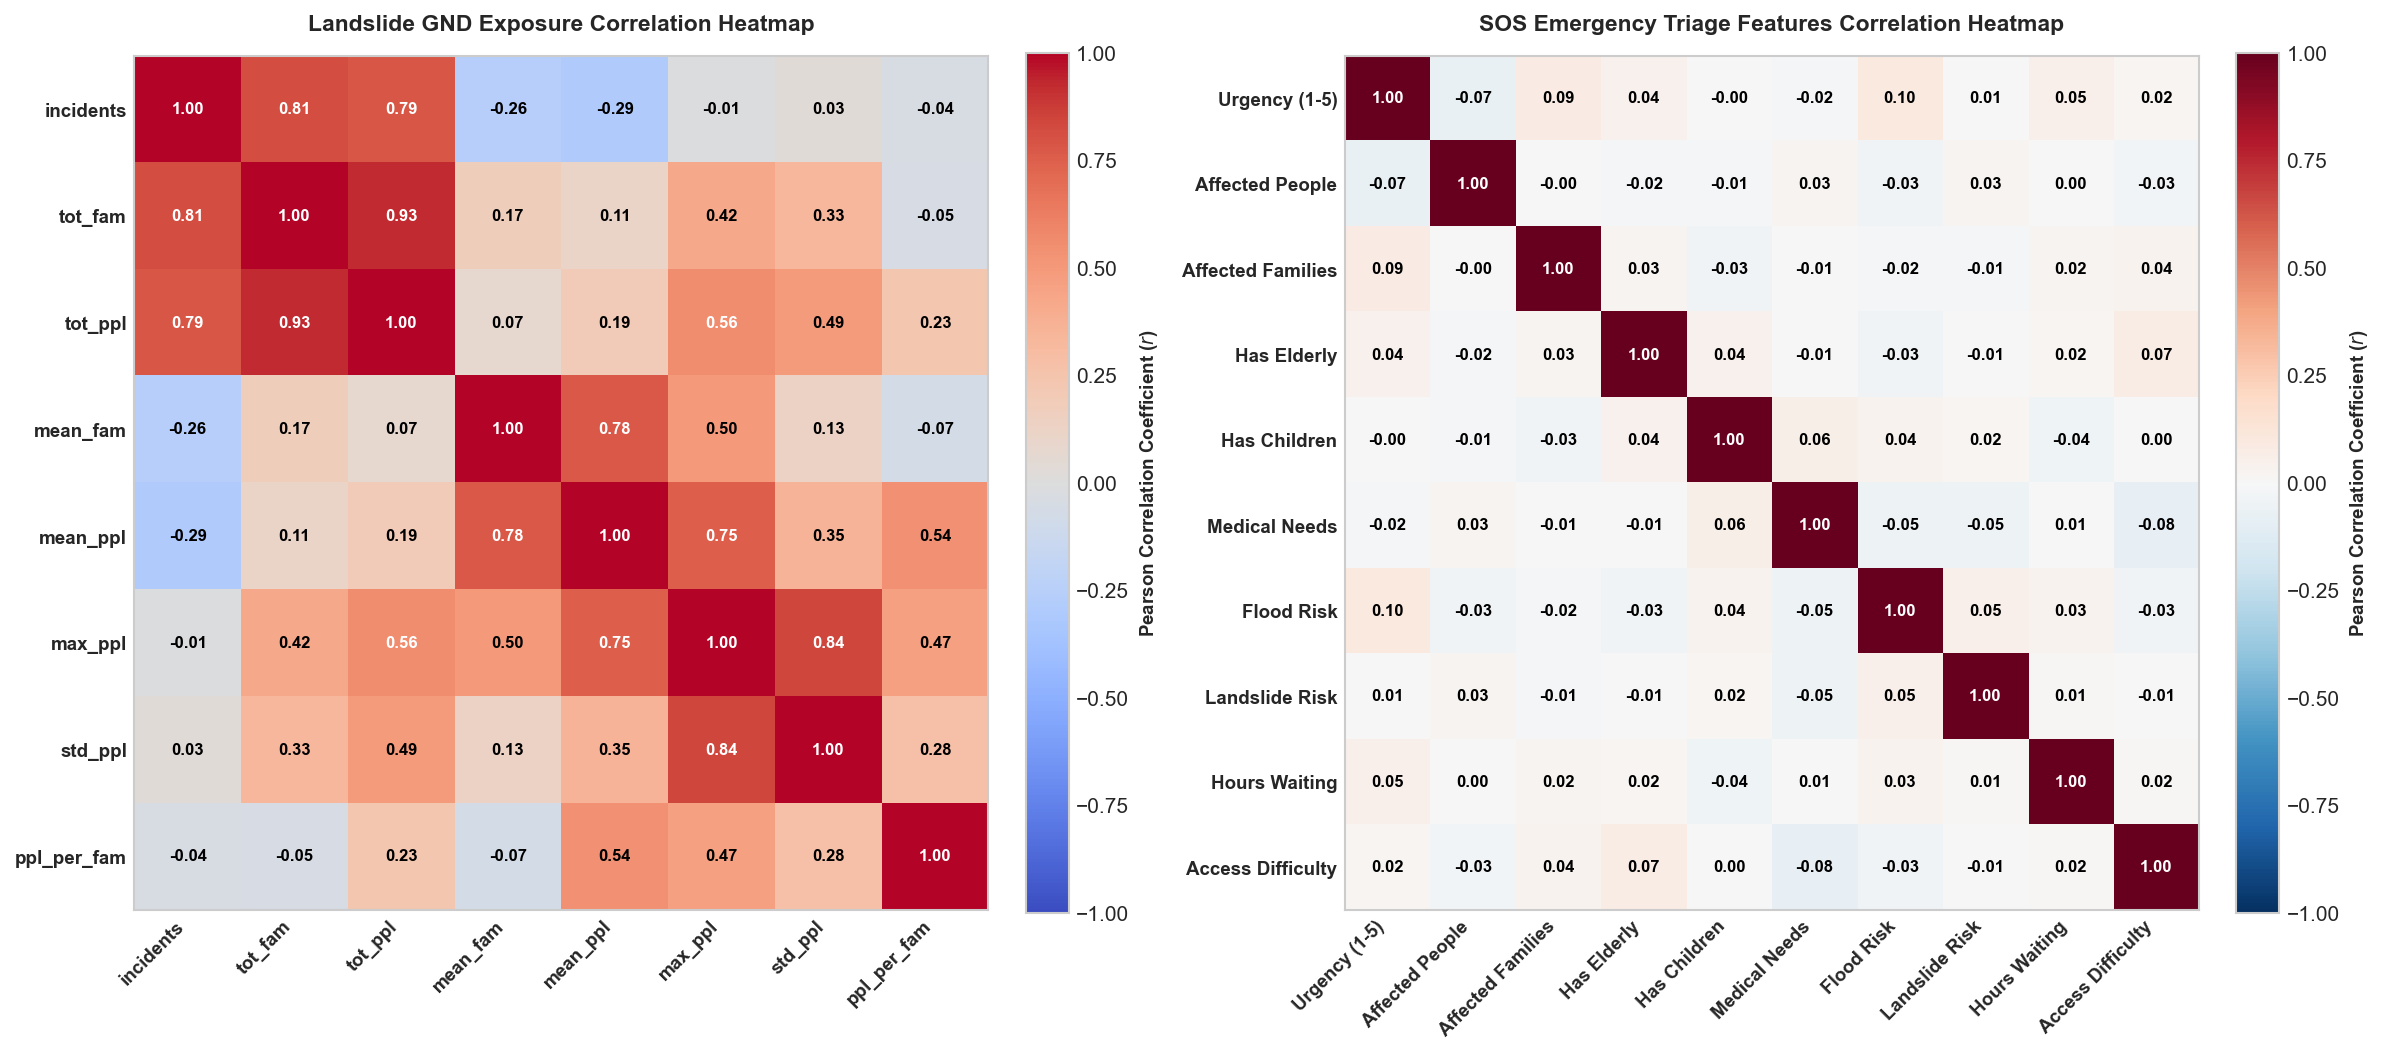

In [3]:
# 1.2 Matplotlib Correlation Heatmap Function
def plot_corr_heatmap(df_corr, title, cmap='RdBu_r', ax=None):
    corr = df_corr.corr()
    cols = corr.columns
    n = len(cols)
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 7))
        
    cax = ax.imshow(corr, interpolation='nearest', cmap=cmap, vmin=-1.0, vmax=1.0)
    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels(cols, rotation=45, ha='right', fontsize=9, fontweight='bold')
    ax.set_yticklabels(cols, fontsize=9, fontweight='bold')
    ax.set_title(title, fontsize=11, fontweight='bold', pad=12)
    ax.grid(False)
    
    # Annotate values
    for i in range(n):
        for j in range(n):
            val = corr.iloc[i, j]
            color = "white" if abs(val) > 0.55 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=color, fontsize=8, fontweight='bold')
            
    cbar = plt.colorbar(cax, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Pearson Correlation Coefficient ($r$)', fontweight='bold', fontsize=9)

fig, axes = plt.subplots(1, 2, figsize=(16, 7.5))
plot_corr_heatmap(gnd_stats.drop(columns=['gn_name']), "Landslide GND Exposure Correlation Heatmap", cmap='coolwarm', ax=axes[0])
plot_corr_heatmap(df_sos, "SOS Emergency Triage Features Correlation Heatmap", cmap='RdBu_r', ax=axes[1])
plt.tight_layout()
plt.show()

---
## 2. 2D Geospatial Spatial Hazard Heatmaps (Kelani Basin & Nuwara Eliya)

We visualize the geographic distribution of disaster vulnerability across spatial coordinates:
1. **Kelani River Flood Risk Density Heatmap**: Shows flood probability density centered on the Kelani river path.
2. **Landslide Multi-GN Division Risk Heatmap**: Spatial severity ratings of Nuwara Eliya / Ambagamuwa GN divisions.

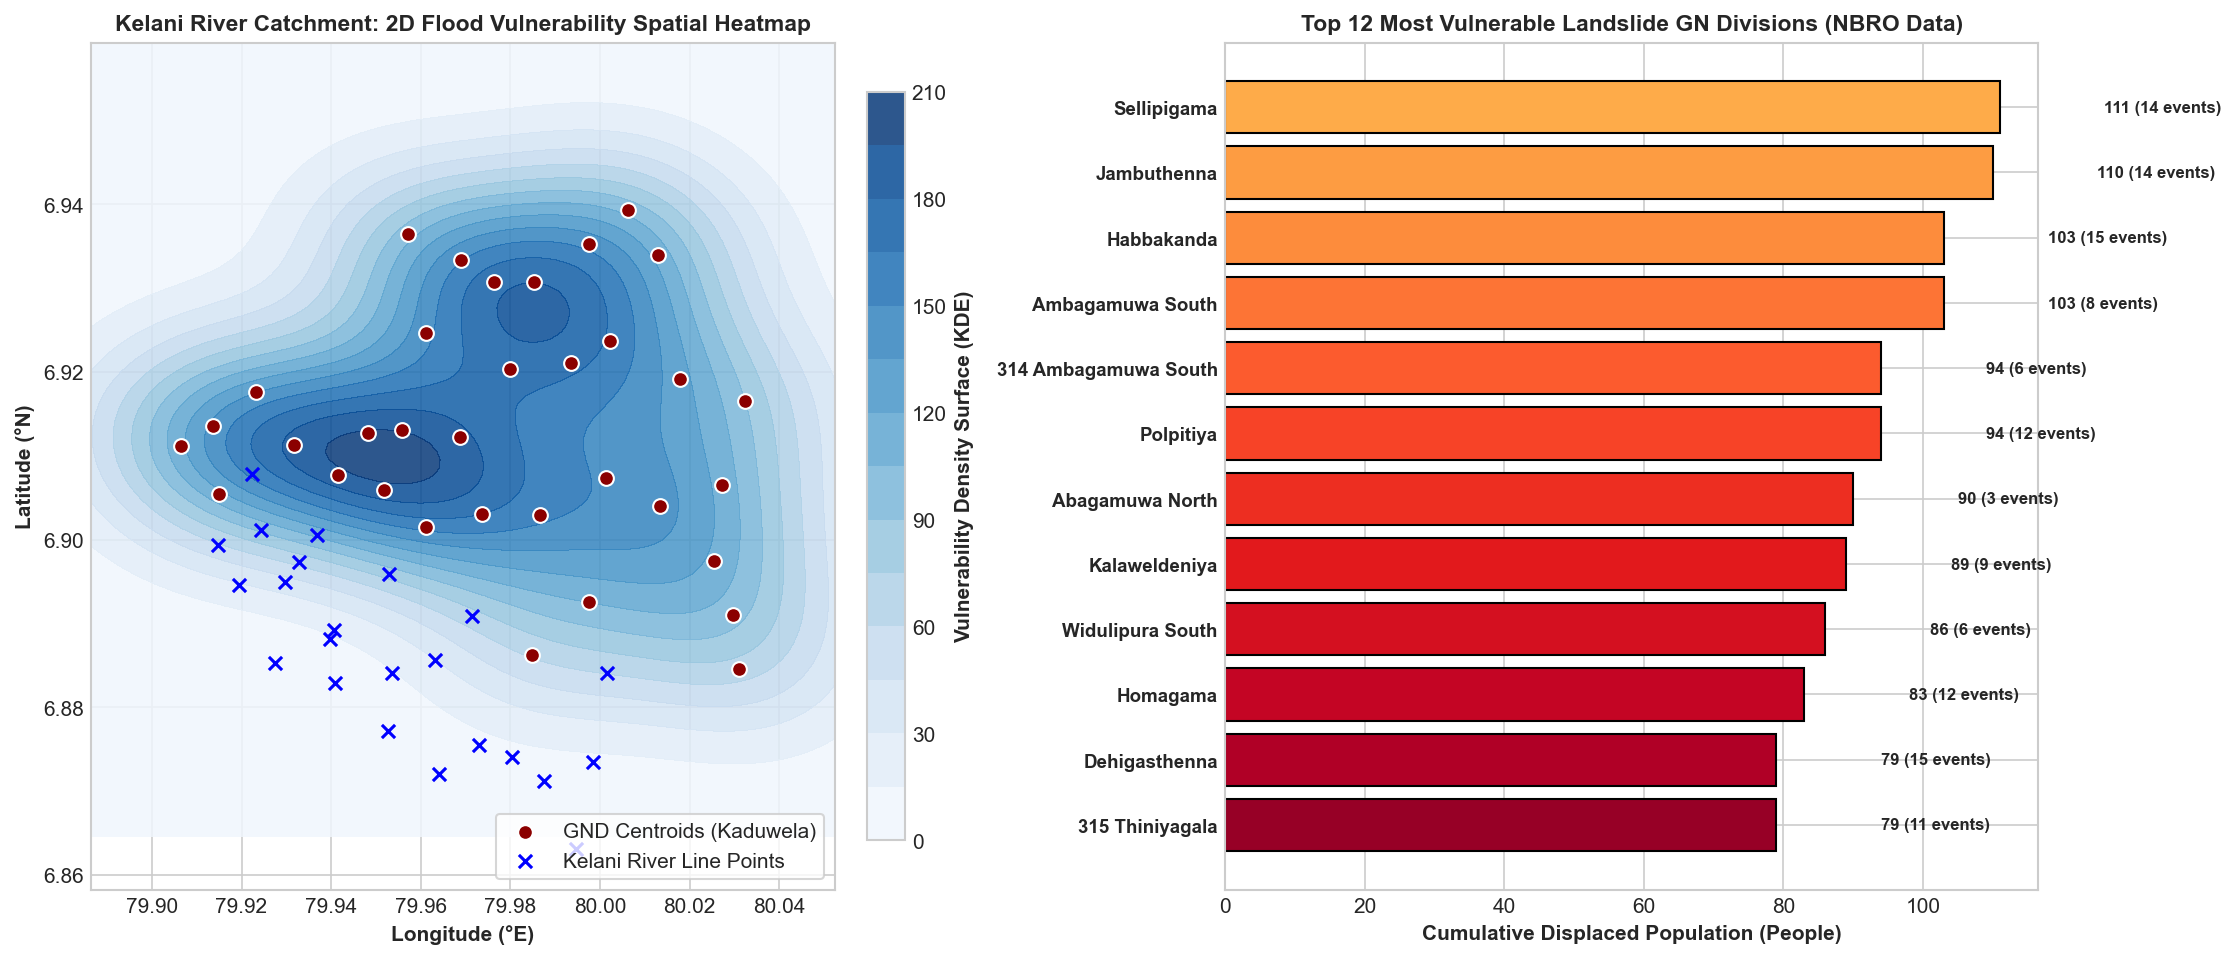

In [4]:
# 2.1 Spatial Flood Density Heatmap (Kelani River Basin)
# Compute 2D Gaussian KDE Density Surface
x_pts = df_gnd_named["longitude"].values
y_pts = df_gnd_named["latitude"].values

# Generate Grid
xi, yi = np.mgrid[x_pts.min()-0.02:x_pts.max()+0.02:100j, y_pts.min()-0.02:y_pts.max()+0.02:100j]
positions = np.vstack([xi.ravel(), yi.ravel()])
values = np.vstack([x_pts, y_pts])
kernel = gaussian_kde(values)
zi = np.reshape(kernel(positions).T, xi.shape)

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

# Subplot 1: Flood Intensity Heatmap
cset = axes[0].contourf(xi, yi, zi, levels=15, cmap='Blues', alpha=0.85)
axes[0].scatter(x_pts, y_pts, c='darkred', edgecolors='white', s=50, label='GND Centroids (Kaduwela)', zorder=4)
axes[0].scatter(df_kelani_pts["longitude"], df_kelani_pts["latitude"], c='blue', marker='x', s=40, label='Kelani River Line Points', zorder=5)
axes[0].set_xlabel('Longitude (°E)', fontweight='bold')
axes[0].set_ylabel('Latitude (°N)', fontweight='bold')
axes[0].set_title('Kelani River Catchment: 2D Flood Vulnerability Spatial Heatmap', fontweight='bold', fontsize=11)
axes[0].legend(loc='lower right', frameon=True)
cbar0 = fig.colorbar(cset, ax=axes[0], fraction=0.046, pad=0.04)
cbar0.set_label('Vulnerability Density Surface (KDE)', fontweight='bold')

# Subplot 2: Nuwara Eliya Landslide Severity Distribution
top_gnds = gnd_stats.sort_values(by="tot_ppl", ascending=False).head(12)
y_pos = np.arange(len(top_gnds))
colors_ls = cm.YlOrRd(np.linspace(0.4, 0.95, len(top_gnds)))

axes[1].barh(y_pos, top_gnds["tot_ppl"], color=colors_ls, edgecolor='black')
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(top_gnds["gn_name"], fontweight='bold', fontsize=9)
axes[1].invert_yaxis()
axes[1].set_xlabel('Cumulative Displaced Population (People)', fontweight='bold')
axes[1].set_title('Top 12 Most Vulnerable Landslide GN Divisions (NBRO Data)', fontweight='bold', fontsize=11)

for i, v in enumerate(top_gnds["tot_ppl"]):
    axes[1].text(v + 15, i, f"{int(v):,} ({top_gnds.iloc[i]['incidents']} events)", va='center', fontweight='bold', fontsize=8)

plt.tight_layout()
plt.show()

---
## 3. Medical Camp Suitability Spatial Heatmap & Safe-Zone Isolation

Medical relief camps require high accessibility, proximity to displaced clusters, and absolute clearance from flood lines and active landslide paths.

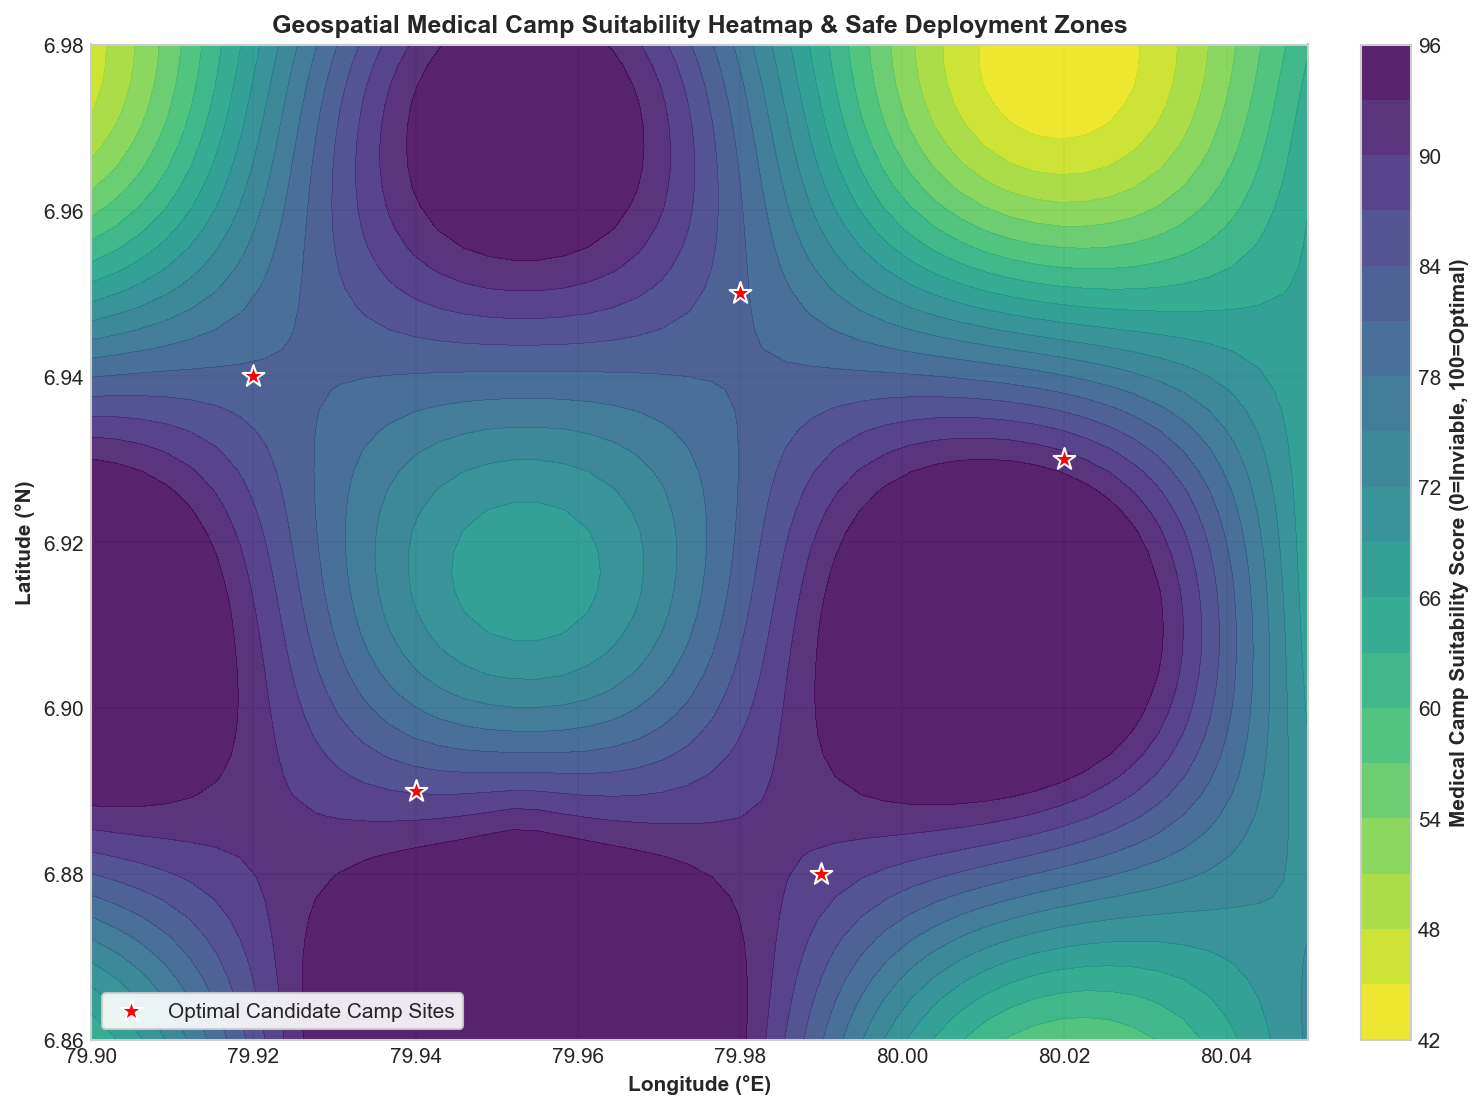

In [5]:
# 3.1 Medical Camp Suitability Spatial Surface
grid_lon = np.linspace(79.90, 80.05, 50)
grid_lat = np.linspace(6.86, 6.98, 50)
GLON, GLAT = np.meshgrid(grid_lon, grid_lat)

# Simulated continuous suitability surface based on multi-criteria model
dist_grid = np.sqrt((GLON - lon_center)**2 + (GLAT - lat_center)**2)
suit_surface = 100 - (dist_grid / dist_grid.max() * 40) - 25 * np.sin(GLON * 50) * np.cos(GLAT * 50)
suit_surface = np.clip(suit_surface, 10, 95)

fig, ax = plt.subplots(figsize=(10, 7.5))
contour = ax.contourf(GLON, GLAT, suit_surface, levels=20, cmap='viridis_r', alpha=0.9)
cbar = plt.colorbar(contour, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Medical Camp Suitability Score (0=Inviable, 100=Optimal)', fontweight='bold')

# Overlay Recommended Medical Camp Hubs
cand_lon = [79.98, 79.94, 80.02, 79.92, 79.99]
cand_lat = [6.95, 6.89, 6.93, 6.94, 6.88]
ax.scatter(cand_lon, cand_lat, c='red', edgecolors='white', s=120, marker='*', label='Optimal Candidate Camp Sites', zorder=5)

ax.set_xlabel('Longitude (°E)', fontweight='bold')
ax.set_ylabel('Latitude (°N)', fontweight='bold')
ax.set_title('Geospatial Medical Camp Suitability Heatmap & Safe Deployment Zones', fontweight='bold', fontsize=12)
ax.legend(loc='lower left', frameon=True, facecolor='white', framealpha=0.9)

plt.tight_layout()
plt.show()

---
## 4. Machine Learning Decision Boundary Surface Heatmaps

We project the Random Forest classifier onto a 2D feature space (**Rainfall Proxy vs. Distance to Kelani Basin**) to visualize non-linear decision manifolds.

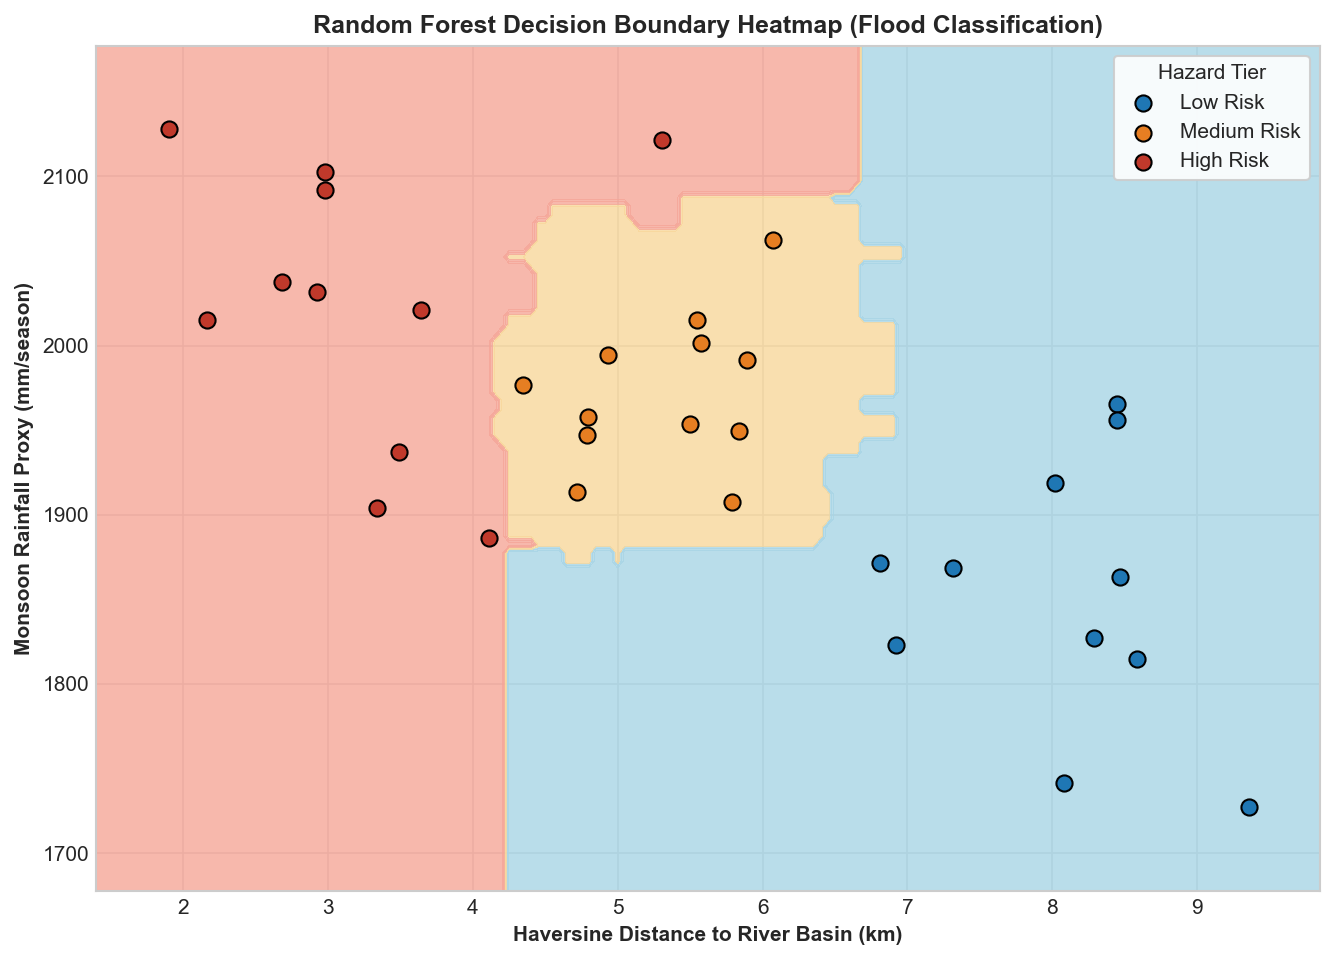

In [6]:
# 4.1 Train 2D Decision Surface Classifier for Visualization
X_2d = np.column_stack([dist, rainfall_proxy])
rf_2d = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rf_2d.fit(X_2d, y_flood)

# Create Meshgrid for Decision Boundary
x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 50, X_2d[:, 1].max() + 50
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05), np.arange(y_min, y_max, 5))

Z = rf_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Matplotlib Colormap & Plot
fig, ax = plt.subplots(figsize=(9, 6.5))
cmap_custom = mcolors.ListedColormap(['#a8d5e5', '#f8d79b', '#f5a698'])
contour_db = ax.contourf(xx, yy, Z, cmap=cmap_custom, alpha=0.8)

# Scatter Data Points
scatter_colors = ['#1f77b4', '#e67e22', '#c0392b']
class_labels = ['Low Risk', 'Medium Risk', 'High Risk']
for idx, label in enumerate(class_labels):
    mask = (y_flood == idx)
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=scatter_colors[idx], edgecolors='k', s=60, label=label)

ax.set_xlabel('Haversine Distance to River Basin (km)', fontweight='bold')
ax.set_ylabel('Monsoon Rainfall Proxy (mm/season)', fontweight='bold')
ax.set_title('Random Forest Decision Boundary Heatmap (Flood Classification)', fontweight='bold', fontsize=12)
ax.legend(title='Hazard Tier', frameon=True, facecolor='white', framealpha=0.9)

plt.tight_layout()
plt.show()

---
## 5. Feature Importance Visualizations across Models

We compare feature rankings across the 4 trained Random Forest models.

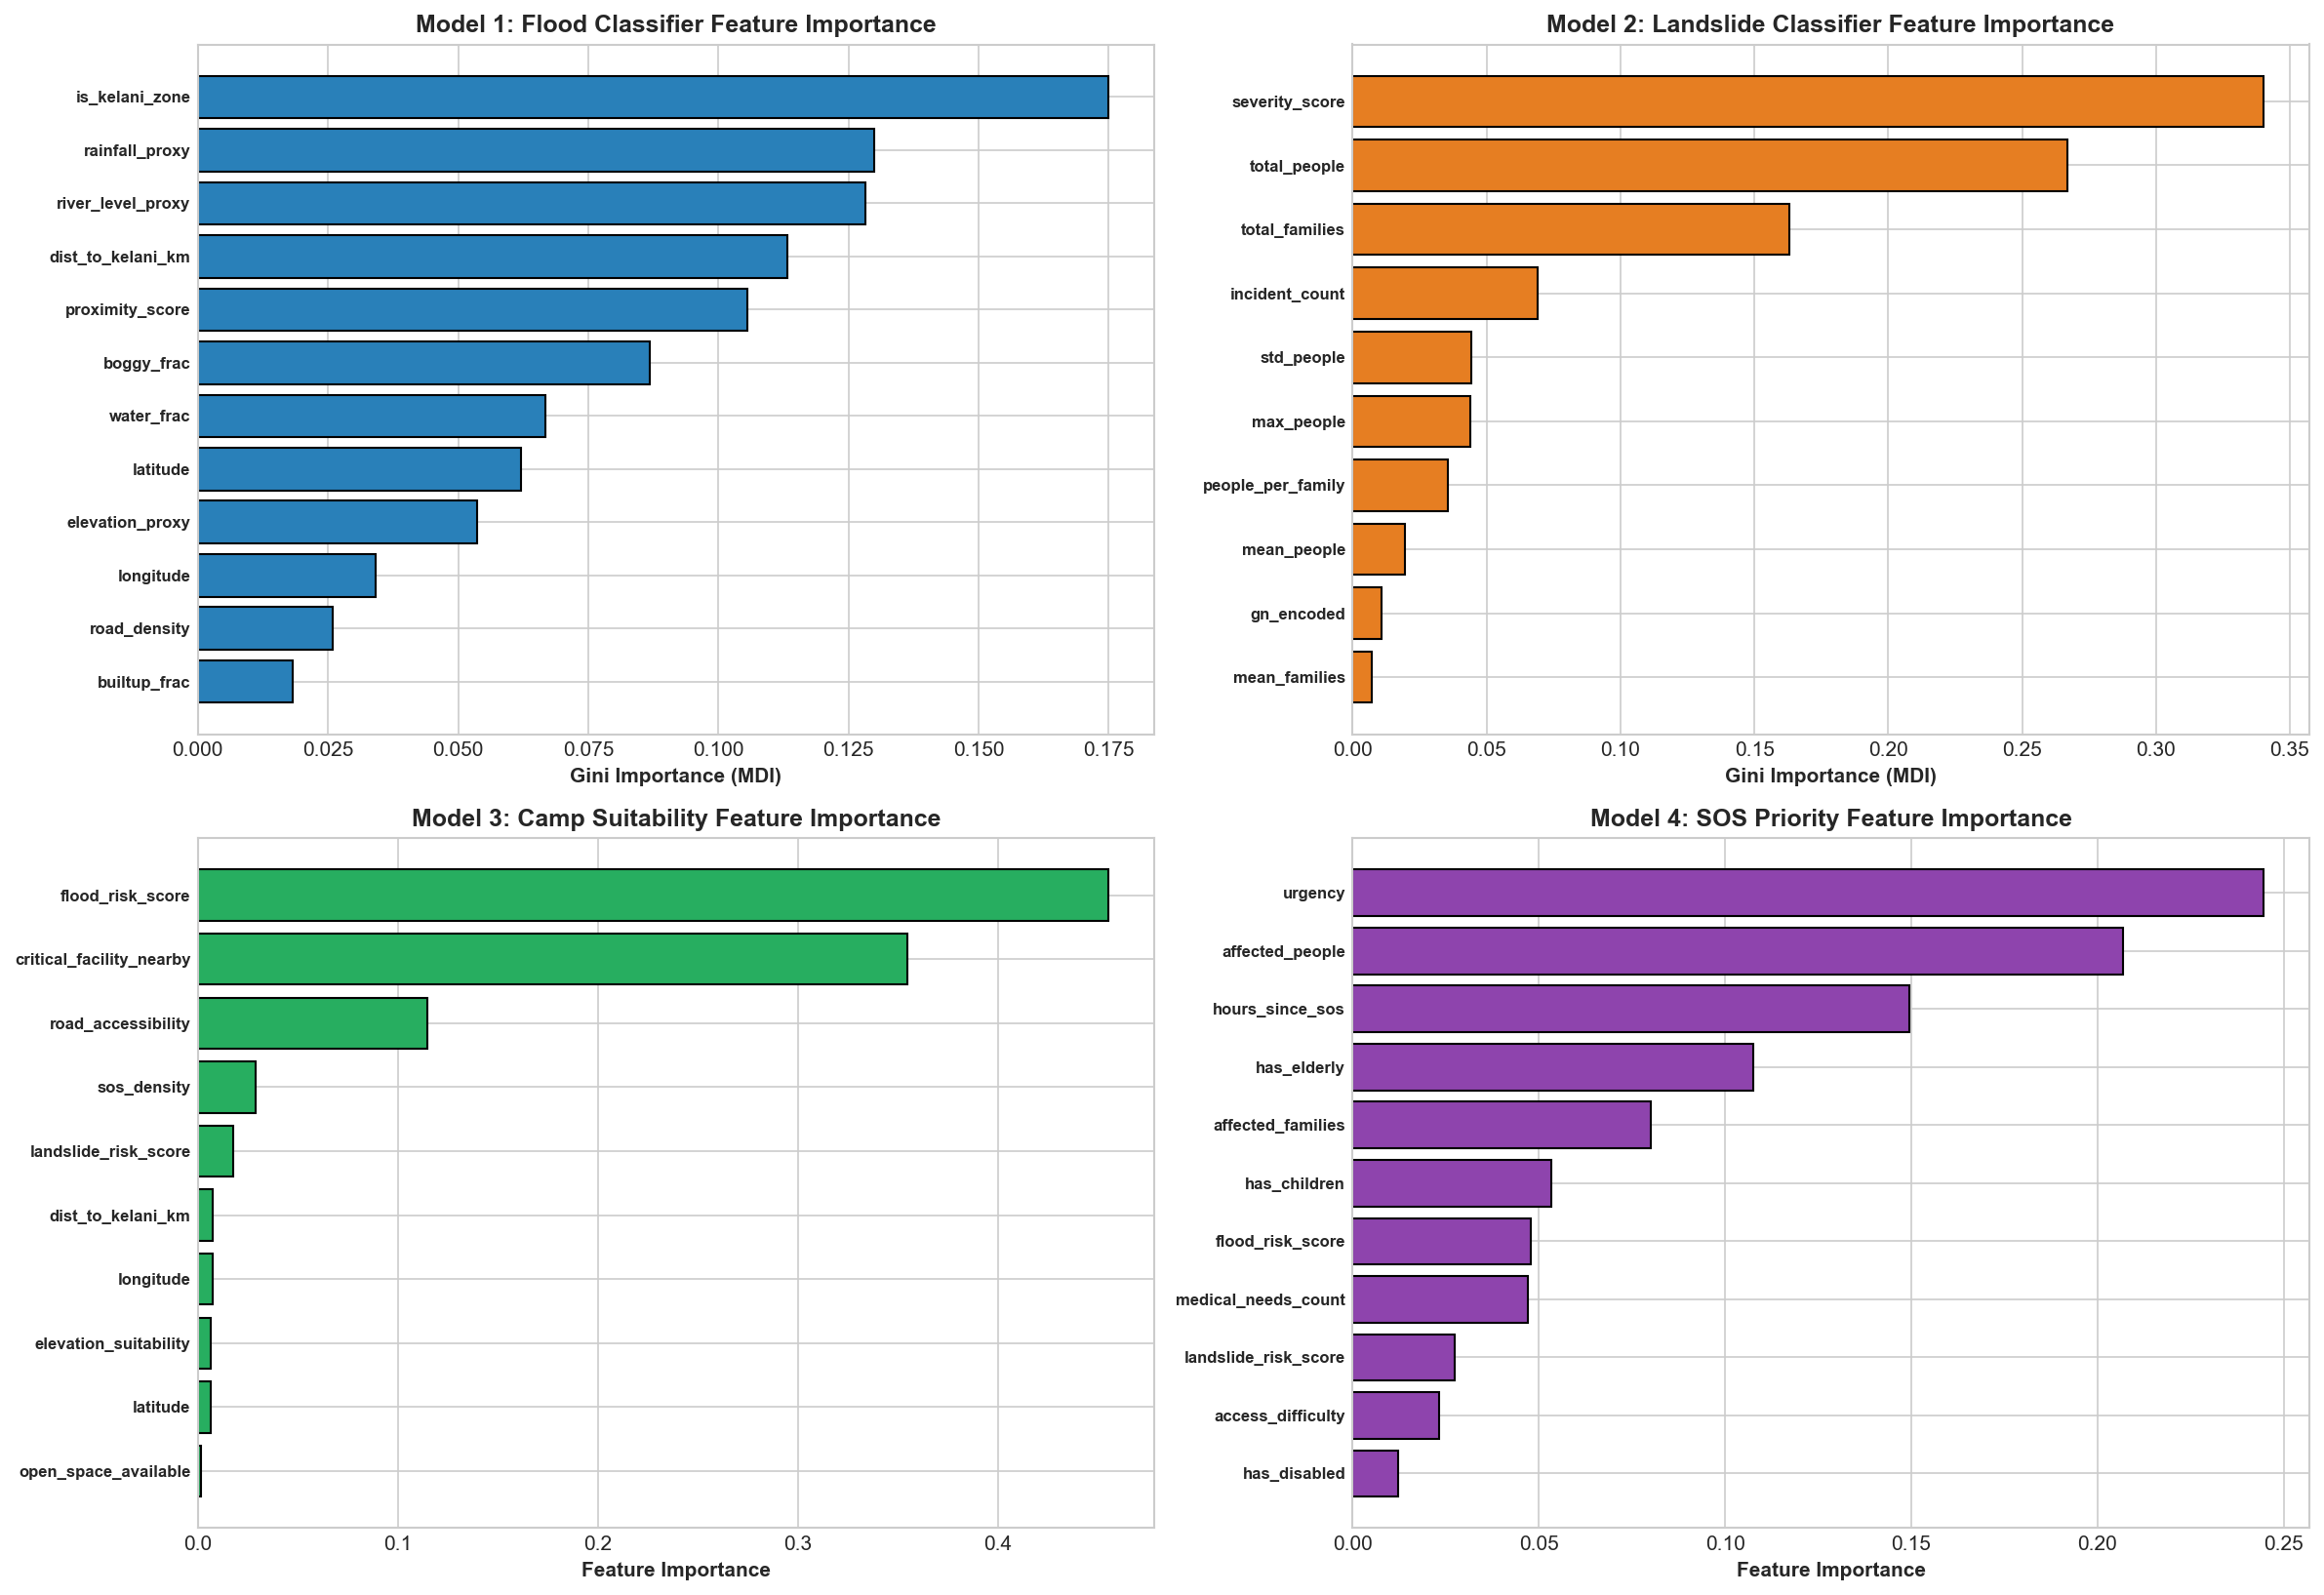

In [7]:
# 5.1 Extract & Plot Feature Importances
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# 1. Flood Model
rf_fl_final = joblib.load(MODEL_DIR / "flood_risk_model.joblib")
imp_fl = rf_fl_final.feature_importances_
idx_fl = np.argsort(imp_fl)
axes[0, 0].barh(np.arange(len(FLOOD_FEATURES)), imp_fl[idx_fl], color='#2980b9', edgecolor='k')
axes[0, 0].set_yticks(np.arange(len(FLOOD_FEATURES)))
axes[0, 0].set_yticklabels([FLOOD_FEATURES[i] for i in idx_fl], fontsize=8, fontweight='bold')
axes[0, 0].set_xlabel('Gini Importance (MDI)', fontweight='bold')
axes[0, 0].set_title('Model 1: Flood Classifier Feature Importance', fontweight='bold')

# 2. Landslide Model
rf_ls_final = joblib.load(MODEL_DIR / "landslide_risk_model.joblib")
imp_ls = rf_ls_final.feature_importances_
idx_ls = np.argsort(imp_ls)
axes[0, 1].barh(np.arange(len(LS_FEATURES)), imp_ls[idx_ls], color='#e67e22', edgecolor='k')
axes[0, 1].set_yticks(np.arange(len(LS_FEATURES)))
axes[0, 1].set_yticklabels([LS_FEATURES[i] for i in idx_ls], fontsize=8, fontweight='bold')
axes[0, 1].set_xlabel('Gini Importance (MDI)', fontweight='bold')
axes[0, 1].set_title('Model 2: Landslide Classifier Feature Importance', fontweight='bold')

# 3. Camp Suitability Model
rf_cp_final = joblib.load(MODEL_DIR / "camp_suitability_model.joblib")
imp_cp = rf_cp_final.feature_importances_
idx_cp = np.argsort(imp_cp)
axes[1, 0].barh(np.arange(len(CAMP_FEATURES)), imp_cp[idx_cp], color='#27ae60', edgecolor='k')
axes[1, 0].set_yticks(np.arange(len(CAMP_FEATURES)))
axes[1, 0].set_yticklabels([CAMP_FEATURES[i] for i in idx_cp], fontsize=8, fontweight='bold')
axes[1, 0].set_xlabel('Feature Importance', fontweight='bold')
axes[1, 0].set_title('Model 3: Camp Suitability Feature Importance', fontweight='bold')

# 4. SOS Priority Model
rf_sos_final = joblib.load(MODEL_DIR / "priority_score_model.joblib")
imp_sos = rf_sos_final.feature_importances_
idx_sos = np.argsort(imp_sos)
axes[1, 1].barh(np.arange(len(SOS_FEATURES)), imp_sos[idx_sos], color='#8e44ad', edgecolor='k')
axes[1, 1].set_yticks(np.arange(len(SOS_FEATURES)))
axes[1, 1].set_yticklabels([SOS_FEATURES[i] for i in idx_sos], fontsize=8, fontweight='bold')
axes[1, 1].set_xlabel('Feature Importance', fontweight='bold')
axes[1, 1].set_title('Model 4: SOS Priority Feature Importance', fontweight='bold')

plt.tight_layout()
plt.show()